<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Visual-Recognition/blob/master/LAB_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Adversarial examples: FGSM

*Based on [PyTorch tutorial](https://pytorch.org/tutorials/beginner/fgsm_tutorial.html) by Nathan Inkawhich.*

Modern computer vision models can classify images with impressive accuracy. However, accuracy on "natural" inputs does not guarantee **robustness**: what happens if an input is intentionally modified to trigger a mistake? This is studied in **adversarial machine learning**.

A key observation is that adding a **tiny, often imperceptible perturbation** can flip a model's prediction. In this lab, you will implement a simple gradient-based attack (FGSM).

You don't need a GPU for this lab.

## Threat model

Adversarial attacks are characterized by (1) what the attacker knows and (2) what the attacker wants.

Attacker knowledge:
- *White-box:* full access to the model (architecture, inputs, outputs, and weights).
- *Black-box:* only query access to inputs/outputs (no gradients or weights).

Attack goal
- *Untargeted:* cause any incorrect prediction (misclassification).
- *Targeted:* force the prediction to a chosen target class.

In this lab we use a *white-box, untargeted* attack and study how the success changes as we increase the perturbation budget ε.


## Fast Gradient Sign Method (FGSM)

FGSM is a simple white-box attack introduced by Goodfellow et al. (2014) [Explaining and Harnessing Adversarial
Examples](https://arxiv.org/abs/1412.6572).
Instead of updating model parameters to *minimize* the loss, FGSM updates the **input** $x$ to *maximize* the loss.

Here:
- $\mathbf{x}$ - original input image, usually correctly classified,
- $y$ - ground truth label for $\mathbf{x}$,
- $\mathbf{\theta}$ - model parameters,
- $J(\mathbf{\theta}, \mathbf{x}, y)$ – loss used to train the network.

FGSM constructs:

$$x_{adv} := \text{clip}\big(x + \varepsilon \cdot \text{sign}(\nabla_x J(\theta, x, y)), 0, 1\big)$$

where ε controls the perturbation strength (typically in $L_\infty$), and `clip` keeps the perturbed input in the valid range.



FGSM panda example:
<img src="https://pytorch.org/tutorials/_static/img/fgsm_panda_image.png" width="800" style="display: block; margin: auto;">



The attack backpropagates the gradient back to the input
data to calculate $\nabla_{x} J(\mathbf{\theta}, \mathbf{x}, y)$. Then,
it adjusts the input data by a small step ($\epsilon$ or $0.007$ in the
picture) in the direction (i.e.
$sign(\nabla_{x} J(\mathbf{\theta}, \mathbf{x}, y))$) that will maximize
the loss. The resulting perturbed image, $x'$, is then *misclassified*
by the target network as a "gibbon" when it is still clearly a "panda".

See also a very effective extended version of this attack:
[turtle→rifle Youtube video](https://www.youtube.com/watch?v=YXy6oX1iNoA)

## Imports

In [ ]:
from typing import cast, NamedTuple

import ipywidgets
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets
from torch import Tensor, LongTensor
from torchvision.transforms import v2
from tqdm import tqdm

device = torch.accelerator.current_accelerator(True) or torch.device("cpu")
print(device)

cpu


## Dataset and model
The model under attack is a simple MNIST model from [pytorch/examples/mnist](https://github.com/pytorch/examples/tree/master/mnist).

Important details:
* the dataloader returns *unnormalized* images (in [0,1] range).
* the model was trained on *normalized* images.
* the model's parameters are frozen with `model.requires_grad_(False)`, we won't be training it. This avoids unnecessary gradient storage during the attack.

In [ ]:
mean, std = (0.1307,), (0.3081,)

normalize = v2.Normalize(mean, std)
unnormalize = v2.Normalize([-m / s for m, s in zip(mean, std)], [1 / s for s in std])

In [ ]:
test_loader = torch.utils.data.DataLoader(
    torch.utils.data.Subset(
        torchvision.datasets.MNIST(
            "data/MNIST",
            train=False,
            download=True,
            transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]),
        ),
        list(range(300)),
    ),
    batch_size=10,
    shuffle=True,
)

In [ ]:
%%bash
if [ ! -f "data/lenet_mnist_model.pth" ]; then
    wget -q https://mimuw.edu.pl/~bilinski/VRNN2026/labs/lenet_mnist_model.pth -O data/lenet_mnist_model.pth
fi

In [ ]:
class Net(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output


model = Net().to(device)
model.load_state_dict(
    torch.load("data/lenet_mnist_model.pth", map_location=device, weights_only=True)
)
model.eval()
model.requires_grad_(False)  # Freeze model parameters, we won't be training it.

Net(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

## FGSM Attack

Implement the attack. Recall that:

$$x_{adv} := \text{clip}\big(x + \varepsilon \cdot \text{sign}(\nabla_x J(\theta, x, y)), 0, 1\big)$$

* First implement the basic version as above: an untargeted attack with a single step.
* Then add support for targeted attacks: if `attack_target` is not none, maximize the confidence of the `attack_target` class instead of minimizing the confidence of the true class.
* Then add support for iterative attacks: if `steps > 1`, repeat the above formula $\texttt{steps}$ times with $\frac{\varepsilon}{\texttt{steps}}$ in place of $\varepsilon$. After each step, clip the image to ensure it stays within the ε-ball of the original image (in $L_\infty$ norm) and in the valid range [0,1].

In [ ]:
class AttackResult(NamedTuple):
    original_image: np.ndarray  # shape (C, H, W), in [0,1] range
    original_pred: int
    original_confidence: float
    perturbed_image: np.ndarray  # shape same as original_image, in [0,1] range
    perturbed_pred: int
    perturbed_confidence: float
    target: int


In [ ]:
def fgsm_attack(
    image: Tensor,
    target: LongTensor,
    model: torch.nn.Module,
    epsilon: float,
    steps: int = 1,
    attack_target: int | None = None,
) -> list[AttackResult]:
    """
    Given an unnormalized image, target label and model, perform the iterated FGSM attack.
    """
    assert steps >= 1, "Expected steps≥1."
    B, C, H, W = image.shape
    # { TODO
    orig_image = image = image.detach().clone()

    ...

    return [
        AttackResult(
            original_image=orig_image[i].detach().cpu().numpy(),
            ...,
            target=int(target[i].item()),
        )
        for i in range(B)
    ]
    # } TODO

In [ ]:
def test(
    model: torch.nn.Module,
    test_loader: torch.utils.data.DataLoader,
    epsilon: float,
    steps: int = 1,
    attack_target: int | None = None,
) -> tuple[np.ndarray, list[AttackResult]]:
    """Run the model and the adversarial attack, collect a few examples of adversarial images and return the confusion matrix."""
    confusion_matrix = np.zeros((10, 10), dtype=int)
    adv_examples = []

    device = next(model.parameters()).device

    for image, target in tqdm(test_loader):
        image, target = image.to(device), target.to(device)
        results = fgsm_attack(
            image, target, model, epsilon, steps, attack_target
        )
        for r in results:
            xmin, xmax = r.original_image.min(), r.original_image.max()
            assert 0 <= xmin <= xmax <= 1, (
                f"Original image is out of [0,1] range: {xmin=}, {xmax=}"
            )
            xmin, xmax = r.perturbed_image.min(), r.perturbed_image.max()
            assert 0 <= xmin <= xmax <= 1, (
                f"Perturbed image is out of [0,1] range: {xmin=}, {xmax=}"
            )
            confusion_matrix[r.target, r.perturbed_pred] += 1
            is_attack_successful = (
                r.original_pred == r.target and r.perturbed_pred != r.target
            )
            if is_attack_successful and len(adv_examples) < 5:
                adv_examples.append(r)

    n_total = confusion_matrix.sum()
    n_correct = confusion_matrix.diagonal().sum()
    accuracy = n_correct / n_total
    print(f"{epsilon=}, {accuracy=:.1%} ({n_correct}/{n_total})")
    return confusion_matrix, adv_examples

## Run the attack
Should take ~6s on Colab CPU altogether.

In [ ]:
# List of epsilon values for the attack. Includes 0 to show the original image without perturbation as well.
epsilons = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]

confusion_matrices = list[np.ndarray]()
all_examples = list[list[AttackResult]]()
for eps in epsilons:
    confusion_matrix, examples = test(model, test_loader, eps, steps=1, attack_target=None)
    confusion_matrices.append(confusion_matrix)
    all_examples.append(examples)

100%|██████████| 30/30 [00:00<00:00, 45.17it/s]


epsilon=0, accuracy=100.0% (300/300)


100%|██████████| 30/30 [00:00<00:00, 44.96it/s]


epsilon=0.05, accuracy=96.3% (289/300)


100%|██████████| 30/30 [00:00<00:00, 45.93it/s]


...

epsilon=0.2, accuracy=13.3% (40/300)


100%|██████████| 30/30 [00:00<00:00, 40.97it/s]


epsilon=0.25, accuracy=2.0% (6/300)


100%|██████████| 30/30 [00:00<00:00, 44.34it/s]

epsilon=0.3, accuracy=0.3% (1/300)


## Accuracy vs Epsilon

What you should see:
* As epsilon increases, test accuracy decreases, as expected.
* The trend is not linear, larger epsilons cause a much sharper drop in accuracy.
* For large enough epsilons (~0.3), the accuracy of the model drop below that of random guessing (10% for MNIST).

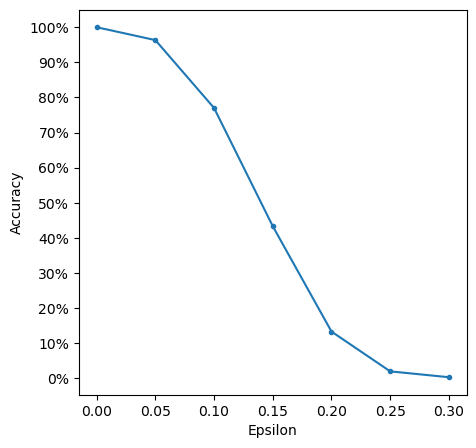

In [ ]:
accuracies = [m.diagonal().sum() / m.sum() for m in confusion_matrices]
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(epsilons, accuracies, ".-")
ax.set_yticks(np.arange(0, 1.1, step=0.1))
ax.set_xticks(np.arange(0, 0.35, step=0.05))
ax.set_xlabel("Epsilon")
ax.set_ylabel("Accuracy")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

## Confusion matrix
 What you should see:
 * for epsilon=0, the confusion matrix is mostly diagonal (high accuracy).
 * for untargeted attacks (attack_target=None), the confusion matrix becomes more uniform as epsilon increases.
 * for attack_target=2, the confusion matrix becomes more skewed towards class 2 as epsilon increases.
 * the predicted class will often be incorrect but not necessarily the attack_target class (so targeted attacks are only partially effective, especially for some attack_target-s).

In [ ]:
def show_confusion_matrix(confusion_matrix: np.ndarray, epsilon: float) -> None:
    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(confusion_matrix)
    ax.set_xticks(np.arange(10))
    ax.set_yticks(np.arange(10))
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(f"Confusion matrix for ε={epsilon}")
    fig.colorbar(im)
    plt.show()


# show_confusion_matrix(confusion_matrices[1], epsilons[1])
ipywidgets.interact(
    lambda i: show_confusion_matrix(confusion_matrices[i], epsilons[i]),
    i=ipywidgets.IntSlider(min=0, max=len(confusion_matrices) - 1, value=0),
);

interactive(children=(IntSlider(value=0, description='i', max=6), Output()), _dom_classes=('widget-interact',)…

## Sample Adversarial Examples

* The title above each image shows the predicted class.
* As epsilon increases the test accuracy decreases, but the perturbations become more easily perceptible (we have a tradeoff between attack strength and perceptibility).
* Nevertheless, even at high epsilon, humans can still easily identify the correct class.

In [ ]:
def show_examples(eps: float) -> None:
    i = epsilons.index(eps)
    fig, axs = plt.subplots(
        nrows=2,
        ncols=len(all_examples[i]),
        figsize=(len(all_examples[i]) * 1.5, 4),
    )
    fig.set_layout_engine(
        "constrained", h_pad=0.04, w_pad=0.01, hspace=0.02, wspace=0.01
    )
    fig.suptitle(f"Examples of succesful attacks for ε={eps}: ", fontsize=14)
    fig.supxlabel("predicted class (confidence %)", fontsize=12)

    for j in range(len(all_examples[i])):
        ex = all_examples[i][j]

        axs[0, 0].set_ylabel("orig.", fontsize=14)
        axs[0, j].xaxis.set_ticks([])
        axs[0, j].yaxis.set_ticks([])
        axs[0, j].set_xlabel(f"{ex.original_pred} ({ex.original_confidence:.0%})")
        axs[0, j].imshow(ex.original_image.squeeze(axis=0), cmap="gray")

        axs[1, 0].set_ylabel(f"ε={epsilons[i]}", fontsize=14)
        axs[1, j].xaxis.set_ticks([])
        axs[1, j].yaxis.set_ticks([])
        axs[1, j].set_xlabel(f"{ex.perturbed_pred} ({ex.perturbed_confidence:.0%})")
        axs[1, j].imshow(ex.perturbed_image.squeeze(axis=0), cmap="gray")


# show_examples(epsilons[1])
ipywidgets.interact(
    lambda i: show_examples(epsilons[i]),
    i=ipywidgets.IntSlider(min=1, max=len(epsilons) - 1),
);

interactive(children=(IntSlider(value=1, description='i', max=6, min=1), Output()), _dom_classes=('widget-inte…